In [1]:
#========================================
# Import required packages
#========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle, Ellipse
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

from pathlib import Path
import json
import sys
sys.path.append(r"C:\Users\F.Turner\Documents\00. Analyses")
import use_funcs
from use_funcs import find_project_root

In [2]:
#========================================
# Define Save the Children colour palette
#========================================

sc_colors = {'red': '#da291c',
             'medium red' : '#ed7b73',
             'light red': '#f9d3d0',
             'purple': '#ae90c3',
             'medium purple': '#cebcdb',
             'light purple': '#efe9f3',
             'yellow': '#fecf28',
             'medium yellow': '#ffeca9',
             'light yellow': '#fff5d4',
             'blue': '#99cccc',
             'medium blue' : '#d6ebeb',
             'light blue' : '#ebf5f5',
             'green' : '#45b283',
             'medium green' : '#8dd3b5',
             'light green' : '#d9f0e6',
             'grey' : '#e7e6e6'}

mpl.rcParams['font.family'] = 'Calibri' 

In [3]:
#========================================
# Configure project paths and output folders
#========================================

PROJECT_ROOT = find_project_root(Path.cwd())
CONFIG_PATH = PROJECT_ROOT / "path_config.json"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    PATHS = json.load(f)

IMP_DIR = (PROJECT_ROOT / PATHS["imports_dir"]).resolve()
HO_DIR = (PROJECT_ROOT / PATHS["handoff_dir"]).resolve()
EXP_DIR = (PROJECT_ROOT / PATHS["exports_dir"]).resolve()
FIG_DIR = (PROJECT_ROOT / PATHS["figures_dir"]).resolve()
TAB_DIR = (PROJECT_ROOT / PATHS["tables_dir"]).resolve()

for folder in [IMP_DIR, HO_DIR, EXP_DIR, FIG_DIR, TAB_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("IMP_DIR:", IMP_DIR)
print("HO_DIR:", HO_DIR)
print("EXP_DIR:", EXP_DIR)
print("FIG_DIR:", FIG_DIR)
print("TAB_DIR:", TAB_DIR)

PROJECT_ROOT: C:\Users\F.Turner\Documents\00. Analyses\Education Financing
IMP_DIR: C:\Users\F.Turner\Documents\00. Analyses\Education Financing\Data
HO_DIR: C:\Users\F.Turner\Documents\00. Analyses\Education Financing\Handoff
EXP_DIR: C:\Users\F.Turner\Documents\00. Analyses\Education Financing\Results
FIG_DIR: C:\Users\F.Turner\Documents\00. Analyses\Education Financing\Results\figures
TAB_DIR: C:\Users\F.Turner\Documents\00. Analyses\Education Financing\Results\tables


In [4]:
#========================================
# Load core analysis datasets
#========================================

all_data = pd.read_csv(IMP_DIR / "all_data.csv")
lays_panels = pd.read_csv(IMP_DIR / "lays_panels.csv")

NOTES FOR NEXT TIME

Short answer: not in the headline specification.

For your log-ratio models in [Education Financing/Code/Data Analysis/04. COFOG Proportions and LAYS.ipynb](Education Financing/Code/Data%20Analysis/04.%20COFOG%20Proportions%20and%20LAYS.ipynb), I would use a model ladder:

Main model:
Allocation terms (log ratios) + income anchor only.
If outcome is LAYS, include log GDPPC.
If outcome is GDPPC residual-LAYS, do not include log GDPPC again.

Robustness model A:
Add only plausibly exogenous structural controls from [Education Financing/Code/Data Analysis/03. Macro Drivers of Learning.ipynb](Education Financing/Code/Data%20Analysis/03.%20Macro%20Drivers%20of%20Learning.ipynb): fragility, SAP share, language fractionalisation.

Robustness model B:
Add household spending and private enrolment separately as sensitivity checks, not core controls, because they are likely downstream/endogenous.

Why this is better:

Keeps your core allocation story interpretable.
Avoids over-controlling away the mechanism you want to test.
Limits sample collapse and multicollinearity from throwing every macro covariate in at once.
So yes, include macro controls, but as robustness tiers, not all in the primary model.

# **Education Expenditure**

## By COFOG Category and GDPPC

In [5]:
#========================================
# Select COFOG expenditure variables
#========================================

cofog = all_data[['iso3',
                  'year',
                  'gdppc_2015_usd',
                  'general_public_services_pct',
                    'defense_pct',
                    'public_order_safety_pct',
                    'economic_affairs_pct',
                    'environmental_protection_pct',
                    'housing_community_amenities_pct',
                    'health_pct',
                    'recreation_culture_religion_pct',
                    'education_pct',
                    'social_protection_pct']]

In [6]:
#=============================================
# Keep latest country-year COFOG observations
#=============================================

cofog = cofog.sort_values(['iso3', 'year'], ascending=[True, False])
cofog = cofog.groupby('iso3').first().reset_index()
cofog = cofog.dropna(subset=['education_pct'])

In [7]:
#========================================
# Reshape COFOG data to long format
#========================================

cofog_melt = cofog.melt(id_vars=['iso3', 'year', 'gdppc_2015_usd'],
                        value_vars=['general_public_services_pct',
                                    'defense_pct',
                                    'public_order_safety_pct',
                                    'economic_affairs_pct',
                                    'environmental_protection_pct',
                                    'housing_community_amenities_pct',
                                    'health_pct',
                                    'recreation_culture_religion_pct',
                                    'education_pct',
                                    'social_protection_pct'],
                        var_name='cofog_category',
                        value_name='percentage')

cofog_melt['cofog_category'] = cofog_melt['cofog_category'].str.replace('_pct', '').str.replace('_', ' ').str.title()

cofog_melt = cofog_melt.sort_values(['gdppc_2015_usd'], ascending=[True]).reset_index(drop=True)

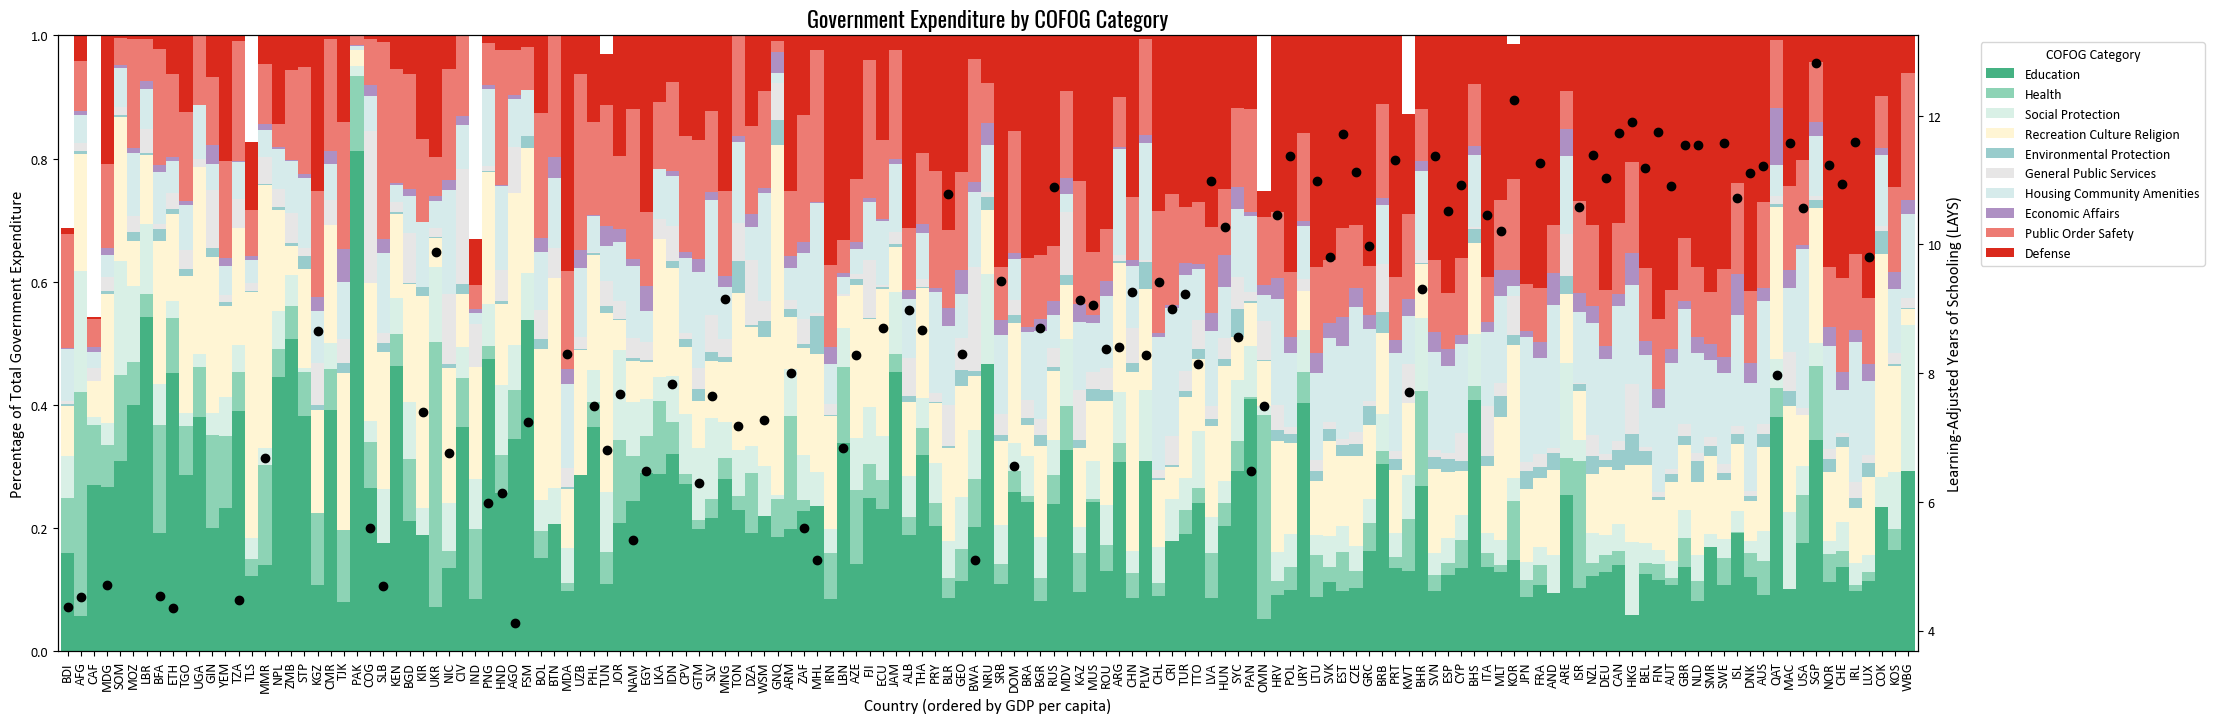

In [8]:
#===============================================
# Plot COFOG expenditure composition by country
#===============================================

cofog_palette = {
    'Recreation Culture Religion': sc_colors['light yellow'],
    'Social Protection': sc_colors['light green'],
    'Economic Affairs': sc_colors['purple'],
    'Housing Community Amenities': sc_colors['medium blue'],
    'Defense': sc_colors['red'],
    'Public Order Safety': sc_colors['medium red'],
    'Health': sc_colors['medium green'],
    'Education': sc_colors['green'],
    'Environmental Protection': sc_colors['blue'],
    'General Public Services': sc_colors['grey'],
}

columns = ['iso3',
           'Education', 
           'Health', 
           'Social Protection', 
           'Recreation Culture Religion', 
           'Environmental Protection', 
           'General Public Services', 
           'Housing Community Amenities',
           'Economic Affairs',
           'Public Order Safety',
           'Defense']

fig, ax = plt.subplots(figsize=(24, 8))

df = cofog.sort_values(['gdppc_2015_usd'], ascending=[True]).copy()
df = df.drop(columns=['year', 'gdppc_2015_usd'])
df.columns = df.columns.str.replace('_pct', '').str.replace('_', ' ').str.title()
df.columns = columns
df = df.set_index('iso3')

plot_columns = [col for col in df.columns if col in cofog_palette]

df.plot(
    kind='bar',
    stacked = True,
    color=[cofog_palette[col] for col in plot_columns],
    width=1,
    ax=ax,
 )
ax.set_ylim(0, 1)

lays = all_data[['iso3', 'lays', 'year', 'gdppc_2015_usd', 'education_pct']].copy()
lays = lays.dropna(subset=['education_pct'])
lays = lays.sort_values(['iso3', 'year'], ascending=[True, False])
lays = lays.groupby('iso3').first().reset_index()

# Align lays to the same country order as the bar chart (df.index)
lays_ordered = lays.set_index('iso3').reindex(df.index)
x_positions = range(len(df.index))

ax2 = ax.twinx()
ax2.scatter(
    x=x_positions,
    y=lays_ordered['lays'].values,
    color='black',
    zorder=5
)
ax2.set_xlim(ax.get_xlim())

ax.set_xlabel('Country (ordered by GDP per capita)', fontsize=12)
ax.set_ylabel('Percentage of Total Government Expenditure', fontsize=12)
ax2.set_ylabel('Learning-Adjusted Years of Schooling (LAYS)', fontsize=12)

ax.set_title('Government Expenditure by COFOG Category', fontname='Oswald', fontsize=16)
ax.legend(title='COFOG Category', bbox_to_anchor=(1.03, 1), loc='upper left')

fig.savefig(FIG_DIR / "cofog_expenditure_composition.png", dpi=300, bbox_inches="tight")


Fig 3a: Breakdown of spending by Common Functions of Government (COFOG) Allocations

This figure looks at how governments allocate spending as their GDP per capita increases. From an initial look we can see that superficially lower-income countries spend more on human development (Health, Education and Social Protection), and as income levels increase, spending on defense and public order/safety increase. Within these superficial trends there is a lot of variance in how countries at similar income levels allocate funding. 

Overalaid on this figure we have added black dots to represent the number of Learning Adjusted Years of Schooling most recently recorded in each country. From this we can't see any clear pattern of variations in LAYS and spending allocations. We need to investigate further, looking at correlation between spending allocation and lays, controlling for gdppc.

## Model 1: Allocation by COFOG Sector

In [9]:
df1 = all_data[['iso3',
               'lays',
               'income_group',
                'year',
                'gdppc_2015_usd',
                'general_public_services_pct',
                'defense_pct',
                'public_order_safety_pct',
                'economic_affairs_pct',
                'environmental_protection_pct',
                'housing_community_amenities_pct',
                'health_pct',
                'recreation_culture_religion_pct',
                'education_pct',
                'social_protection_pct']].copy()

In [10]:
#========================================
# Prepare latest country sample and standardise variables
#========================================
df1 = df1.sort_values(['iso3', 'year'], ascending=[True, False])
df1 = df1.groupby('iso3').first().reset_index()
df1 = df1.dropna().copy()

df1['log_gdppc'] = np.log(df1['gdppc_2015_usd'])

model1_vars = [
    'lays',
    'log_gdppc',
    'general_public_services_pct',
    'defense_pct',
    'public_order_safety_pct',
    'economic_affairs_pct',
    'environmental_protection_pct',
    'housing_community_amenities_pct',
    'health_pct',
    'recreation_culture_religion_pct',
    'education_pct',
    'social_protection_pct',
]

for col in model1_vars:
    df1[f'z_{col}'] = (df1[col] - df1[col].mean()) / df1[col].std(ddof=0)

df1.shape

(119, 28)

                            OLS Regression Results                            
Dep. Variable:                 z_lays   R-squared:                       0.843
Model:                            OLS   Adj. R-squared:                  0.827
Method:                 Least Squares   F-statistic:                     52.23
Date:                Fri, 22 May 2026   Prob (F-statistic):           6.43e-38
Time:                        15:28:06   Log-Likelihood:                -58.685
No. Observations:                 119   AIC:                             141.4
Df Residuals:                     107   BIC:                             174.7
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

,variable,VIF
0,const,1.000000
1,z_log_gdppc,2.837485
2,z_general_public_services_pct,5.280289
3,z_defense_pct,3.312244
4,z_public_order_safety_pct,1.656872
5,z_economic_affairs_pct,3.199988
6,z_environmental_protection_pct,1.397030
7,z_housing_community_amenities_pct,1.522168
8,z_health_pct,2.960357
9,z_recreation_culture_religion_pct,1.455844


,Variable,Coefficient,CI Lower,CI Upper,Significant
0,Log GDP per capita,0.577998,0.450090,0.705906,True
1,General public services (%),-0.090437,-0.264923,0.084048,False
2,Defense (%),0.128389,-0.009806,0.266584,False
3,Public order and safety (%),-0.051738,-0.149478,0.046003,False
4,Economic affairs (%),0.087929,-0.047904,0.223762,False
5,Environmental protection (%),0.036918,-0.052831,0.126668,False
6,Housing and community amenities (%),-0.044009,-0.137692,0.049675,False
7,Health (%),0.121415,-0.009233,0.252063,False
8,"Recreation, culture and religion (%)",0.057052,-0.034568,0.148671,False
9,Education (%),-0.080680,-0.181446,0.020087,False


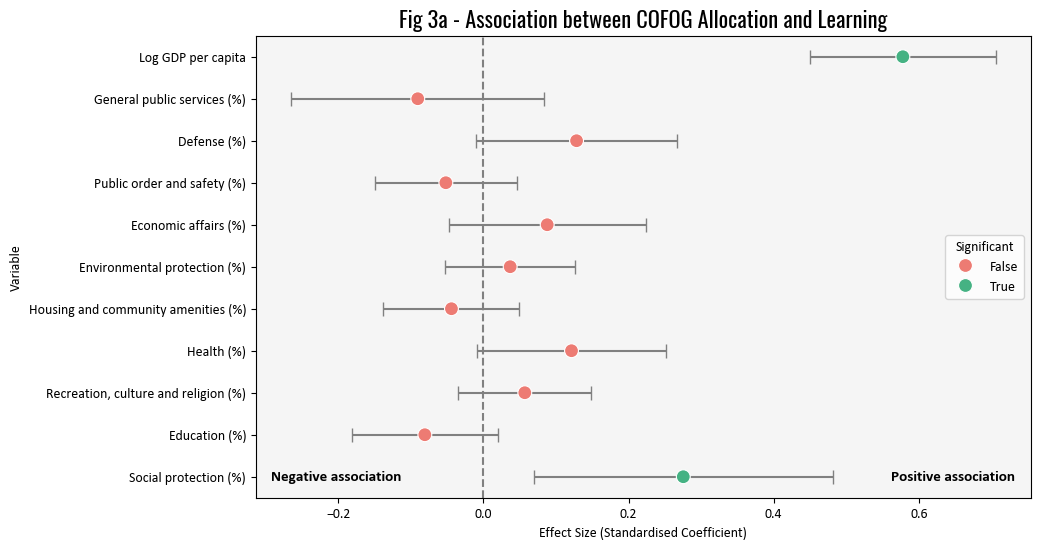

In [21]:
#====================================================================
# Fit multivariable OLS with standardised COFOG proportions
#====================================================================

y = df1['z_lays']

model1_predictors = [
    'z_log_gdppc',
    'z_general_public_services_pct',
    'z_defense_pct',
    'z_public_order_safety_pct',
    'z_economic_affairs_pct',
    'z_environmental_protection_pct',
    'z_housing_community_amenities_pct',
    'z_health_pct',
    'z_recreation_culture_religion_pct',
    'z_education_pct',
    'z_social_protection_pct',
]

X = df1[model1_predictors]
X = sm.add_constant(X)

model_basic = sm.OLS(y, X).fit()

print(model_basic.summary())

#========================================
# Check for multicollinearity using VIF
#========================================

vif = pd.DataFrame()
vif['variable'] = X.columns
vif['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print('\nVariance Inflation Factors:')
display(vif)

#========================================
# Create model 1 coefficient table
#========================================
model1_labels = {
    'z_log_gdppc': 'Log GDP per capita',
    'z_general_public_services_pct': 'General public services (%)',
    'z_defense_pct': 'Defense (%)',
    'z_public_order_safety_pct': 'Public order and safety (%)',
    'z_economic_affairs_pct': 'Economic affairs (%)',
    'z_environmental_protection_pct': 'Environmental protection (%)',
    'z_housing_community_amenities_pct': 'Housing and community amenities (%)',
    'z_health_pct': 'Health (%)',
    'z_recreation_culture_religion_pct': 'Recreation, culture and religion (%)',
    'z_education_pct': 'Education (%)',
    'z_social_protection_pct': 'Social protection (%)',
}

coef_index = [c for c in model_basic.params.index if c != 'const']
model1_df = pd.DataFrame({
    'Variable': [model1_labels.get(v, v) for v in coef_index],
    'Coefficient': model_basic.params[coef_index].values,
    'CI Lower': model_basic.conf_int().loc[coef_index, 0].values,
    'CI Upper': model_basic.conf_int().loc[coef_index, 1].values,
    'Significant': model_basic.pvalues[coef_index].values < 0.05,
})

display(model1_df)

#========================================
# Create model 1 coefficient plot
#========================================
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(
    x=model1_df['Coefficient'],
    y=model1_df['Variable'],
    xerr=[
        model1_df['Coefficient'] - model1_df['CI Lower'],
        model1_df['CI Upper'] - model1_df['Coefficient'],
    ],
    fmt='none',
    ecolor='grey',
    capsize=5,
    zorder=1,
 )

sns.scatterplot(
    x=model1_df['Coefficient'],
    y=model1_df['Variable'],
    hue=model1_df['Significant'],
    palette={True: sc_colors['green'], False: sc_colors['medium red']},
    s=100,
    ax=ax,
    zorder=2,
)

ax.axvline(x=0, color='grey', linestyle='--', zorder=0)
ax.set_facecolor('whitesmoke')
ax.text(0.98, 0.03, 'Positive association', transform=ax.transAxes, color='black', fontsize=11, fontweight='bold', va='bottom', ha='right')
ax.text(0.02, 0.03, 'Negative association', transform=ax.transAxes, color='black', fontsize=11, fontweight='bold', va='bottom', ha='left')

plt.xlabel('Effect Size (Standardised Coefficient)')
plt.title('Fig 3a - Association between COFOG Allocation and Learning', fontname='Oswald', fontsize=16)
plt.legend(title='Significant')
plt.show()

TABLE 3a. Correlation of Spending Proportions and LAYS

From this basic OLS regression, we can see significant relationships between GDPPC and LAYS (not surprising). In terms of sector spending allocations, we see significant influence only of social protection spending. Education has a non-significant but ***negative*** correlation with LAYS. However, this is an imperfect approach, Using simple spending percentages that sum to one in an OLS regression is problematic because the regressors are mechanically interdependent, creating spurious correlations and making coefficient estimates reflect budget trade‑offs rather than independent effects.

## Model 2: Log-ratio model as compared to general public services

In [12]:
df2 = all_data[['iso3',
               'lays',
               'income_group',
                'year',
                'gdppc_2015_usd',
                'general_public_services_pct',
                'defense_pct',
                'public_order_safety_pct',
                'economic_affairs_pct',
                'environmental_protection_pct',
                'housing_community_amenities_pct',
                'health_pct',
                'recreation_culture_religion_pct',
                'education_pct',
                'social_protection_pct']].copy()

In [13]:
#========================================
# Log-ratio COFOG model (standardised variables)
#========================================
spending_vars = [
    'general_public_services_pct',
    'defense_pct',
    'public_order_safety_pct',
    'economic_affairs_pct',
    'environmental_protection_pct',
    'housing_community_amenities_pct',
    'health_pct',
    'recreation_culture_religion_pct',
    'education_pct',
    'social_protection_pct',
]

epsilon = 0.01  # conservative floor for zero shares

for col in spending_vars:
    df2[f'{col}_adj'] = df2[col] + epsilon

den = 'general_public_services_pct_adj'
log_spending_vars = []

for col in spending_vars:
    if col != 'general_public_services_pct':
        var = f'log_{col}_rel'
        ratio = df2[f'{col}_adj'] / df2[den]
        df2[var] = np.where(ratio > 0, np.log(ratio), np.nan)
        log_spending_vars.append(var)

df2['log_gdppc'] = np.where(df2['gdppc_2015_usd'] > 0, np.log(df2['gdppc_2015_usd']), np.nan)

df2 = df2.replace([np.inf, -np.inf], np.nan).dropna(
    subset=log_spending_vars + ['log_gdppc', 'lays']
).copy()

# Standardise after constructing log-ratio variables
model2_vars = ['lays', 'log_gdppc'] + log_spending_vars
for col in model2_vars:
    df2[f'z_{col}'] = (df2[col] - df2[col].mean()) / df2[col].std(ddof=0)

model2_predictors = ['z_log_gdppc'] + [f'z_{v}' for v in log_spending_vars]
X = df2[model2_predictors]
X = sm.add_constant(X)

model_logratio = sm.OLS(df2['z_lays'], X).fit()
print(model_logratio.summary())

#========================================
# Check for multicollinearity using VIF
#========================================
vif = pd.DataFrame()
vif['variable'] = X.columns
vif['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]
display(vif)


                            OLS Regression Results                            
Dep. Variable:                 z_lays   R-squared:                       0.795
Model:                            OLS   Adj. R-squared:                  0.788
Method:                 Least Squares   F-statistic:                     110.8
Date:                Fri, 22 May 2026   Prob (F-statistic):           4.92e-92
Time:                        11:12:03   Log-Likelihood:                -185.22
No. Observations:                 296   AIC:                             392.4
Df Residuals:                     285   BIC:                             433.0
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

c:\Users\F.Turner\Documents\00. Analyses\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\F.Turner\Documents\00. Analyses\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,variable,VIF
0,const,1.000000
1,z_log_gdppc,2.125045
2,z_log_defense_pct_rel,1.706995
3,z_log_public_order_safety_pct_rel,2.163795
4,z_log_economic_affairs_pct_rel,2.338448
5,z_log_environmental_protection_pct_rel,3.426158
6,z_log_housing_community_amenities_pct_rel,2.417022
7,z_log_health_pct_rel,4.388271
8,z_log_recreation_culture_religion_pct_rel,5.965790
9,z_log_education_pct_rel,3.426380


In [14]:

#========================================
# Create model 2 coefficient table
#========================================
model2_labels = {
    'z_log_gdppc': 'Log GDP per capita',
    'z_log_defense_pct_rel': 'Log ratio: Defense vs general public services',
    'z_log_public_order_safety_pct_rel': 'Log ratio: Public order and safety vs general public services',
    'z_log_economic_affairs_pct_rel': 'Log ratio: Economic affairs vs general public services',
    'z_log_environmental_protection_pct_rel': 'Log ratio: Environmental protection vs general public services',
    'z_log_housing_community_amenities_pct_rel': 'Log ratio: Housing and community amenities vs general public services',
    'z_log_health_pct_rel': 'Log ratio: Health vs general public services',
    'z_log_recreation_culture_religion_pct_rel': 'Log ratio: Recreation/culture/religion vs general public services',
    'z_log_education_pct_rel': 'Log ratio: Education vs general public services',
    'z_log_social_protection_pct_rel': 'Log ratio: Social protection vs general public services',
}

coef_index = [c for c in model_logratio.params.index if c != 'const']
model2_df = pd.DataFrame({
    'Variable': [model2_labels.get(v, v) for v in coef_index],
    'Coefficient': model_logratio.params[coef_index].values,
    'CI Lower': model_logratio.conf_int().loc[coef_index, 0].values,
    'CI Upper': model_logratio.conf_int().loc[coef_index, 1].values,
    'Significant': model_logratio.pvalues[coef_index].values < 0.05,
})

display(model2_df)


,Variable,Coefficient,CI Lower,CI Upper,Significant
0,Log GDP per capita,0.492104,0.415214,0.568994,True
1,Log ratio: Defense vs general public services,0.039337,-0.029576,0.108251,False
2,Log ratio: Public order and safety vs general ...,-0.066729,-0.144318,0.010859,False
3,Log ratio: Economic affairs vs general public ...,0.043723,-0.036936,0.124382,False
4,Log ratio: Environmental protection vs general...,0.030092,-0.067540,0.127724,False
5,Log ratio: Housing and community amenities vs ...,-0.070674,-0.152677,0.011329,False
6,Log ratio: Health vs general public services,0.120006,0.009513,0.230499,True
7,Log ratio: Recreation/culture/religion vs gene...,0.133795,0.004964,0.262627,True
8,Log ratio: Education vs general public services,-0.128685,-0.226320,-0.031050,True
9,Log ratio: Social protection vs general public...,0.350313,0.246739,0.453887,True


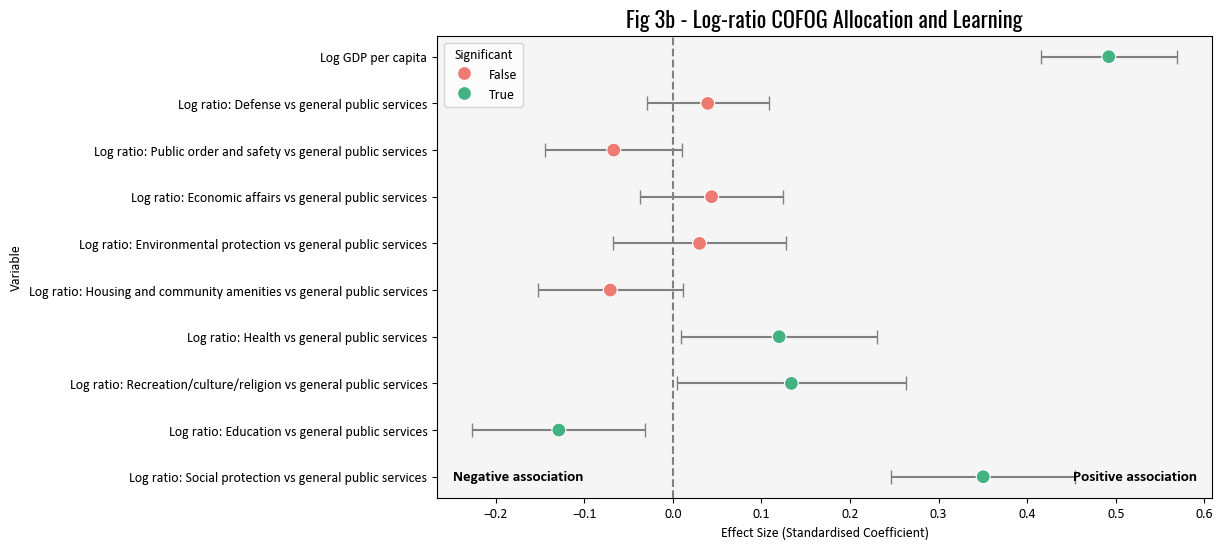

In [22]:

#========================================
# Create model 2 coefficient plot
#========================================
fig, ax = plt.subplots(figsize=(10, 6))


ax.errorbar(
    x=model2_df['Coefficient'],
    y=model2_df['Variable'],
    xerr=[
        model2_df['Coefficient'] - model2_df['CI Lower'],
        model2_df['CI Upper'] - model2_df['Coefficient'],
    ],
    fmt='none',
    ecolor='grey',
    capsize=5,
    zorder=1,
)

sns.scatterplot(
    x=model2_df['Coefficient'],
    y=model2_df['Variable'],
    hue=model2_df['Significant'],
    palette={True: sc_colors['green'], False: sc_colors['medium red']},
    s=100,
    ax=ax,
    zorder=2,
)

ax.axvline(x=0, color='grey', linestyle='--', zorder=0)
ax.set_facecolor('whitesmoke')
ax.text(0.98, 0.03, 'Positive association', transform=ax.transAxes, color='black', fontsize=11, fontweight='bold', va='bottom', ha='right')
ax.text(0.02, 0.03, 'Negative association', transform=ax.transAxes, color='black', fontsize=11, fontweight='bold', va='bottom', ha='left')

plt.xlabel('Effect Size (Standardised Coefficient)')
plt.title('Fig 3b - Log-ratio COFOG Allocation and Learning', fontname='Oswald', fontsize=16)
plt.legend(title='Significant')
plt.show()

Table 3b. A Log-ratio approach to looking at government budget allocation

Log‑ratio specifications address this problem by transforming spending shares into ratios relative to a reference category, so that each regressor measures a reallocation of spending from one use to another rather than an independent change. This removes the constant‑sum constraint that induces collinearity and allows coefficients to be interpreted as the association with learning outcomes of shifting budget priority toward a given sector, holding total resources constant. As a result, log‑ratio models are both statistically more stable and substantively clearer for analysing compositional data such as government budgets.

In this specification we can see that now both health and social protection have ***significant positive*** correlations with learning, while education spending now has ***significant negative*** effect, and the significance of defense allocation has dissapeared. This does not mean that additional education spending causes worse outcomes, but can be a sign of reverse causality, where countries invest more in education recognising an increased need. It is also looking at the impact of increasing spending on education at the cost of core government spending. This highlights the need for governments to balance spending commitments across sectors. 

## Model 2c: Human Development Index Models

In [16]:
df3 = all_data[['iso3',
               'lays',
               'income_group',
                'year',
                'gdppc_2015_usd',
                'general_public_services_pct',
                'defense_pct',
                'public_order_safety_pct',
                'economic_affairs_pct',
                'environmental_protection_pct',
                'housing_community_amenities_pct',
                'health_pct',
                'recreation_culture_religion_pct',
                'education_pct',
                'social_protection_pct']].copy()

df3['log_gdppc'] = np.log(df3['gdppc_2015_usd'])
df3 = df3.dropna()

In [17]:
#========================================
# Human development OLS models (standardised)
#========================================

df3['human_dev_pct'] = (
    df3['health_pct']
    + df3['social_protection_pct']
)

df3['hd+education'] = (
    df3['health_pct']
    + df3['social_protection_pct']
    + df3['education_pct']
)

df3['other_pct'] = 100 - df3['human_dev_pct']

df3['z_lays'] = (df3['lays'] - df3['lays'].mean()) / df3['lays'].std(ddof=0)
df3['z_log_gdppc'] = (df3['log_gdppc'] - df3['log_gdppc'].mean()) / df3['log_gdppc'].std(ddof=0)
df3['z_human_dev_pct'] = (df3['human_dev_pct'] - df3['human_dev_pct'].mean()) / df3['human_dev_pct'].std(ddof=0)
df3['z_hd_plus_education'] = (df3['hd+education'] - df3['hd+education'].mean()) / df3['hd+education'].std(ddof=0)

X = df3[['z_log_gdppc', 'z_human_dev_pct']]
X = sm.add_constant(X)

X2 = df3[['z_log_gdppc', 'z_hd_plus_education']]
X2 = sm.add_constant(X2)

model3 = sm.OLS(df3['z_lays'], X).fit()
model4 = sm.OLS(df3['z_lays'], X2).fit()

print('MODEL 3: Human Development (Health + Social Protection) as a Percentage of Total Government Expenditure\n')
print(model3.summary())

print('\n\nMODEL 4: Human Development + Education as a Percentage of Total Government Expenditure\n')
print(model4.summary())


MODEL 3: Human Development (Health + Social Protection) as a Percentage of Total Government Expenditure

                            OLS Regression Results                            
Dep. Variable:                 z_lays   R-squared:                       0.763
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     471.9
Date:                Fri, 22 May 2026   Prob (F-statistic):           2.36e-92
Time:                        11:12:03   Log-Likelihood:                -206.87
No. Observations:                 296   AIC:                             419.7
Df Residuals:                     293   BIC:                             430.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------

In [18]:

#========================================
# Create model 3 coefficient table (Model 1 in this section)
#========================================

model3_labels = ['Log GDP per capita',
    'Human development \nspending (%)']

coef_index = [c for c in model3.params.index if c != 'const']
model3_df = pd.DataFrame({
    'Variable': model3_labels,
    'Coefficient': model3.params[coef_index].values,
    'CI Lower': model3.conf_int().loc[coef_index, 0].values,
    'CI Upper': model3.conf_int().loc[coef_index, 1].values,
    'Significant': model3.pvalues[coef_index].values < 0.05,
})

display(model3_df)


#========================================
# Create model 4 coefficient table (Model 2 in this section)
#========================================
model4_labels = ['Log GDP per capita',
    'Human development \n+ education spending (%)']

coef_index = [c for c in model4.params.index if c != 'const']
model4_df = pd.DataFrame({
    'Variable': model4_labels,
    'Coefficient': model4.params[coef_index].values,
    'CI Lower': model4.conf_int().loc[coef_index, 0].values,
    'CI Upper': model4.conf_int().loc[coef_index, 1].values,
    'Significant': model4.pvalues[coef_index].values < 0.05,
})

display(model4_df)

,Variable,Coefficient,CI Lower,CI Upper,Significant
0,Log GDP per capita,0.545010,0.471508,0.618513,True
1,Human development \nspending (%),0.415367,0.341864,0.488869,True


,Variable,Coefficient,CI Lower,CI Upper,Significant
0,Log GDP per capita,0.605841,0.531414,0.680269,True
1,Human development \n+ education spending (%),0.342038,0.267611,0.416466,True


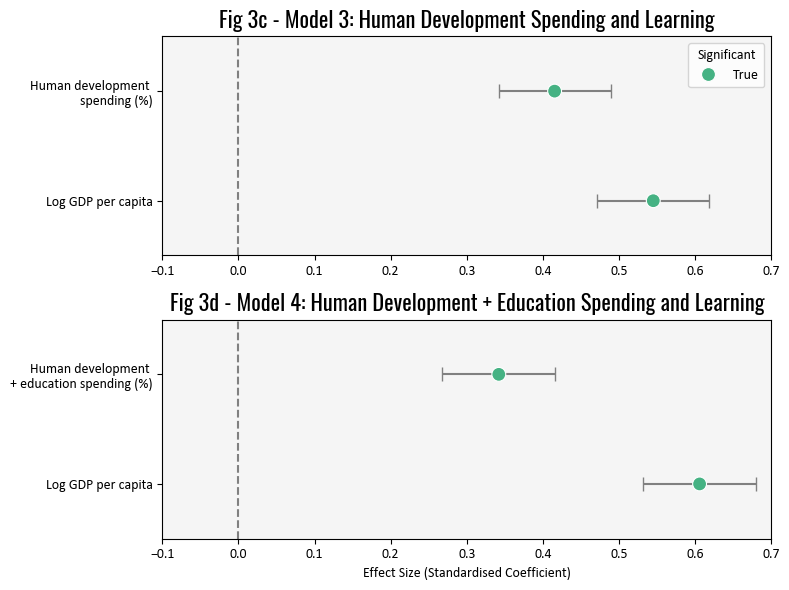

In [23]:
#========================================
# Create model 3 coefficient plot
#========================================
fig, ax = plt.subplots(2, 1, figsize=(8, 6))


ax[0].errorbar(
    x=model3_df['Coefficient'],
    y=model3_df['Variable'],
    xerr=[
        model3_df['Coefficient'] - model3_df['CI Lower'],
        model3_df['CI Upper'] - model3_df['Coefficient'],
    ],
    fmt='none',
    ecolor='grey',
    capsize=5,
    zorder=1,
)

sns.scatterplot(
    x=model3_df['Coefficient'],
    y=model3_df['Variable'],
    hue=model3_df['Significant'],
    palette={True: sc_colors['green'], False: sc_colors['medium red']},
    s=100,
    ax=ax[0],
    zorder=2,
)

ax[0].axvline(x=0, color='grey', linestyle='--', zorder=0)
ax[0].set_facecolor('whitesmoke')

ax[0].set_ylim(0 - .5, 1 + .5)
ax[0].set_xlim(-.1, .7)

ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].set_title('Fig 3c - Model 3: Human Development Spending and Learning', fontname='Oswald', fontsize=16)
ax[0].legend(title='Significant')

#========================================
# Create model 4 coefficient plot
#========================================

ax[1].errorbar(
    x=model4_df['Coefficient'],
    y=model4_df['Variable'],
    xerr=[
        model4_df['Coefficient'] - model4_df['CI Lower'],
        model4_df['CI Upper'] - model4_df['Coefficient'],
    ],
    fmt='none',
    ecolor='grey',
    capsize=5,
    zorder=1,
)

sns.scatterplot(
    x=model4_df['Coefficient'],
    y=model4_df['Variable'],
    hue=model4_df['Significant'],
    palette={True: sc_colors['green'], False: sc_colors['medium red']},
    s=100,
    ax=ax[1],
    zorder=2,
)

ax[1].axvline(x=0, color='grey', linestyle='--', zorder=0)
ax[1].set_facecolor('whitesmoke')

ax[1].set_ylim(0 - .5, 1 + .5)
ax[1].set_xlim(-.1, .7)
ax[1].set_xlabel('Effect Size (Standardised Coefficient)')
ax[1].set_ylabel('')
legend = ax[1].get_legend()
legend.set_visible(False)
ax[1].set_title('Fig 3d - Model 4: Human Development + Education Spending and Learning', fontname='Oswald', fontsize=16)

plt.tight_layout()

Table 3c. Treating Human Development Spending Together

Our final two specifications look at a package of human development spending including education, health and social protection, while controlling for log gdppc. In the first we look only at health and social protection, as these had returned significant positive coefficients in the last specification. In the second, we add education spending to this package of sectors. What we see is that in the first, the model accounts for roughly 79 percent of variance, with human development spending having a highly significant correlation with improved learning outcomes, even when accounting for GDPPC. Adding in education, the proportion of variance falls slightly to 76 percent, but the coefficient remains highly statistically significant. 

This implies that Human Development spending is a key driver of learning, and that spending on education should be best considered as part of a wider package of human development spending, and that without aligned spending on holistic rights, education spending alone may not lead to improved learning. 

# **Export Sheets**

In [ ]:
#========================================
# Export fitted OLS outputs to one workbook
#========================================
def build_model_table(fitted_model):
    out = pd.DataFrame({
        "term": fitted_model.params.index,
        "coefficient": fitted_model.params.values,
        "std_error": fitted_model.bse.values,
        "t_value": fitted_model.tvalues.values,
        "p_value": fitted_model.pvalues.values,
    })
    ci = fitted_model.conf_int()
    out["ci_low"] = ci[0].values
    out["ci_high"] = ci[1].values
    return out

models_to_export = [
    ("Basic_COFOG_OLS", "Model A: Basic COFOG proportions", model_basic),
    ("LogRatio_COFOG_OLS", "Model B: Log-ratio COFOG specification", model_logratio),
    ("HumanDev_OLS", "Model C: Human development spending package", model1),
    ("HumanDevPlusEdu_OLS", "Model D: Human development + education package", model2),
]

workbook_path = TAB_DIR / "drivers_of_learning_ols_outputs.xlsx"

def write_ols_workbook(path):
    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        for sheet_name, title, fitted_model in models_to_export:
            title_df = pd.DataFrame({"Model Title": [title]})
            model_df = build_model_table(fitted_model)
            stats_df = pd.DataFrame({
                "metric": ["n_obs", "r_squared", "adj_r_squared", "f_pvalue"],
                "value": [
                    fitted_model.nobs,
                    fitted_model.rsquared,
                    fitted_model.rsquared_adj,
                    fitted_model.f_pvalue,
                ],
            })

            title_df.to_excel(writer, sheet_name=sheet_name, index=False, startrow=0)
            model_df.to_excel(writer, sheet_name=sheet_name, index=False, startrow=2)
            stats_df.to_excel(writer, sheet_name=sheet_name, index=False, startrow=2 + len(model_df) + 2)

try:
    write_ols_workbook(workbook_path)
    print(f"Workbook exported to: {workbook_path}")
except PermissionError:
    fallback_path = TAB_DIR / f"drivers_of_learning_ols_outputs_{pd.Timestamp.now():%Y%m%d_%H%M%S}.xlsx"
    write_ols_workbook(fallback_path)
    print(f"Primary workbook was locked. Exported to: {fallback_path}")

Workbook exported to: C:\Users\F.Turner\Documents\00. Analyses\Education Financing\Results\tables\drivers_of_learning_ols_outputs.xlsx
